In [38]:
import random

import matplotlib.pyplot as plt
import pandas as pd
import torch
from kan import KAN as PyKAN
from torch import nn

plt.rcParams.update({'font.size': 18})
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Torque target Stochastic Regression

In this notebook we're going to train a `PyKAN`, an `EfficientKAN`, and a `MLP` to learn a function that maps each set of input features to its own probability distribution.

We assume that the underlying process has many small, independent disturbances. Thus, Leveraging the Central limit theorem, we can say that the error between the model's prediction and **the actual observed value is likely to be normal**.

## Load dataset

In [3]:
original_df = pd.read_csv('../dataset/0-original/X.csv').drop(columns=['id', 'pa', 'ias'])
preprocessed_df = pd.read_csv('../dataset/2-regression/X.csv')
df_x = pd.concat([original_df, preprocessed_df], axis=1)
df_y = pd.read_csv('../dataset/2-regression/y.csv')['trq_target']

dataset_x = torch.tensor(df_x.values, dtype=torch.float32, device=device)
dataset_x = (dataset_x - dataset_x.mean(dim=0)) / dataset_x.std(dim=0)
dataset_y = torch.tensor(df_y.values, dtype=torch.float32, device=device).unsqueeze(1)
dataset_y = (dataset_y - dataset_y.mean(dim=0)) / dataset_y.std(dim=0)

In [4]:
class Py_KAN(nn.Module):
    def __init__(self, layers, grid_size=3):
        super(Py_KAN, self).__init__()
        self.layers = layers
        self.grid_size = grid_size
        self.model = PyKAN(width=self.layers, grid=self.grid_size, k=3, device=device)

    def forward(self, x):
        x = self.model(x)
        mu = x[:, 0]
        var = x[:, 1]
        return mu, var

In [5]:
pyKAN = Py_KAN(layers=[[len(df_x.columns), 0], [1, 0], [2, 0]], grid_size=2)

checkpoint directory created: ./model
saving model version 0.0


In [6]:
pyKAN.model = PyKAN.loadckpt('models/torque_target_stochastic_small_12-23-01_8.pt')

C:\Users\MrPio\AppData\Local\Programs\Python\Python310\lib\site-packages\kan\MultKAN.py:578: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state'

## Plotting an inference

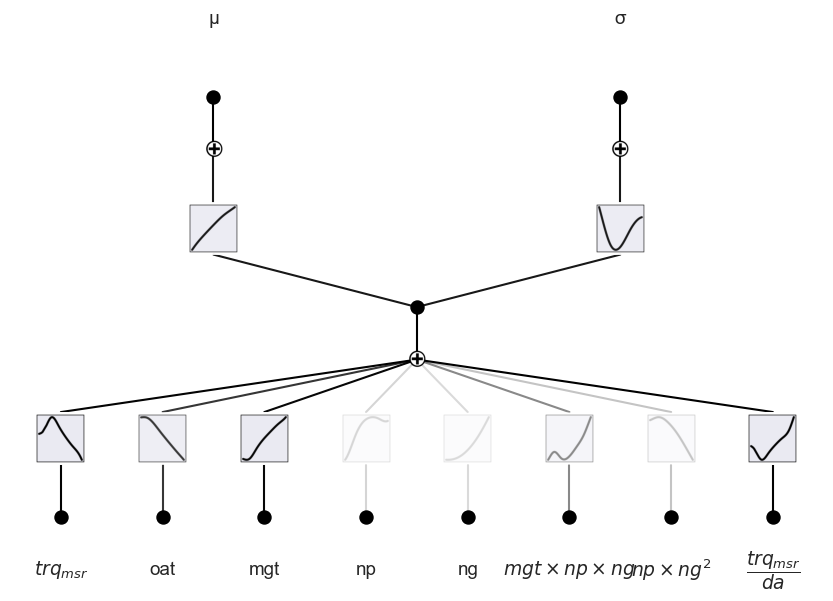

In [7]:
in_vars = ['$trq_{msr}$', 'oat', 'mgt', 'np', 'ng', '$mgt\\times np\\times ng$', '$np\\times ng^2$',
           '$\\dfrac{trq_{msr}}{da}$']
pyKAN.model.plot(scale=0.75, in_vars=in_vars, out_vars=['μ', 'σ'],
                 varscale=0.45, figsize_base=(14, 10))

In [62]:
def predict(model, batch_size=8192) -> pd.DataFrame:
    model.eval()
    predictions = []

    with torch.no_grad():
        for i in range(dataset_x.size(0) // batch_size):
            x = dataset_x[i * batch_size:(i + 1) * batch_size]
            mu, _ = model(x)
            mu = mu * df_y.std() + df_y.mean()
            predictions.extend(mu.detach().cpu().numpy().tolist())
    return pd.DataFrame({'trq_target': predictions})

In [63]:
prediction = predict(pyKAN)

Text(0.5, 1.0, '$trq_{target}$ prediction')

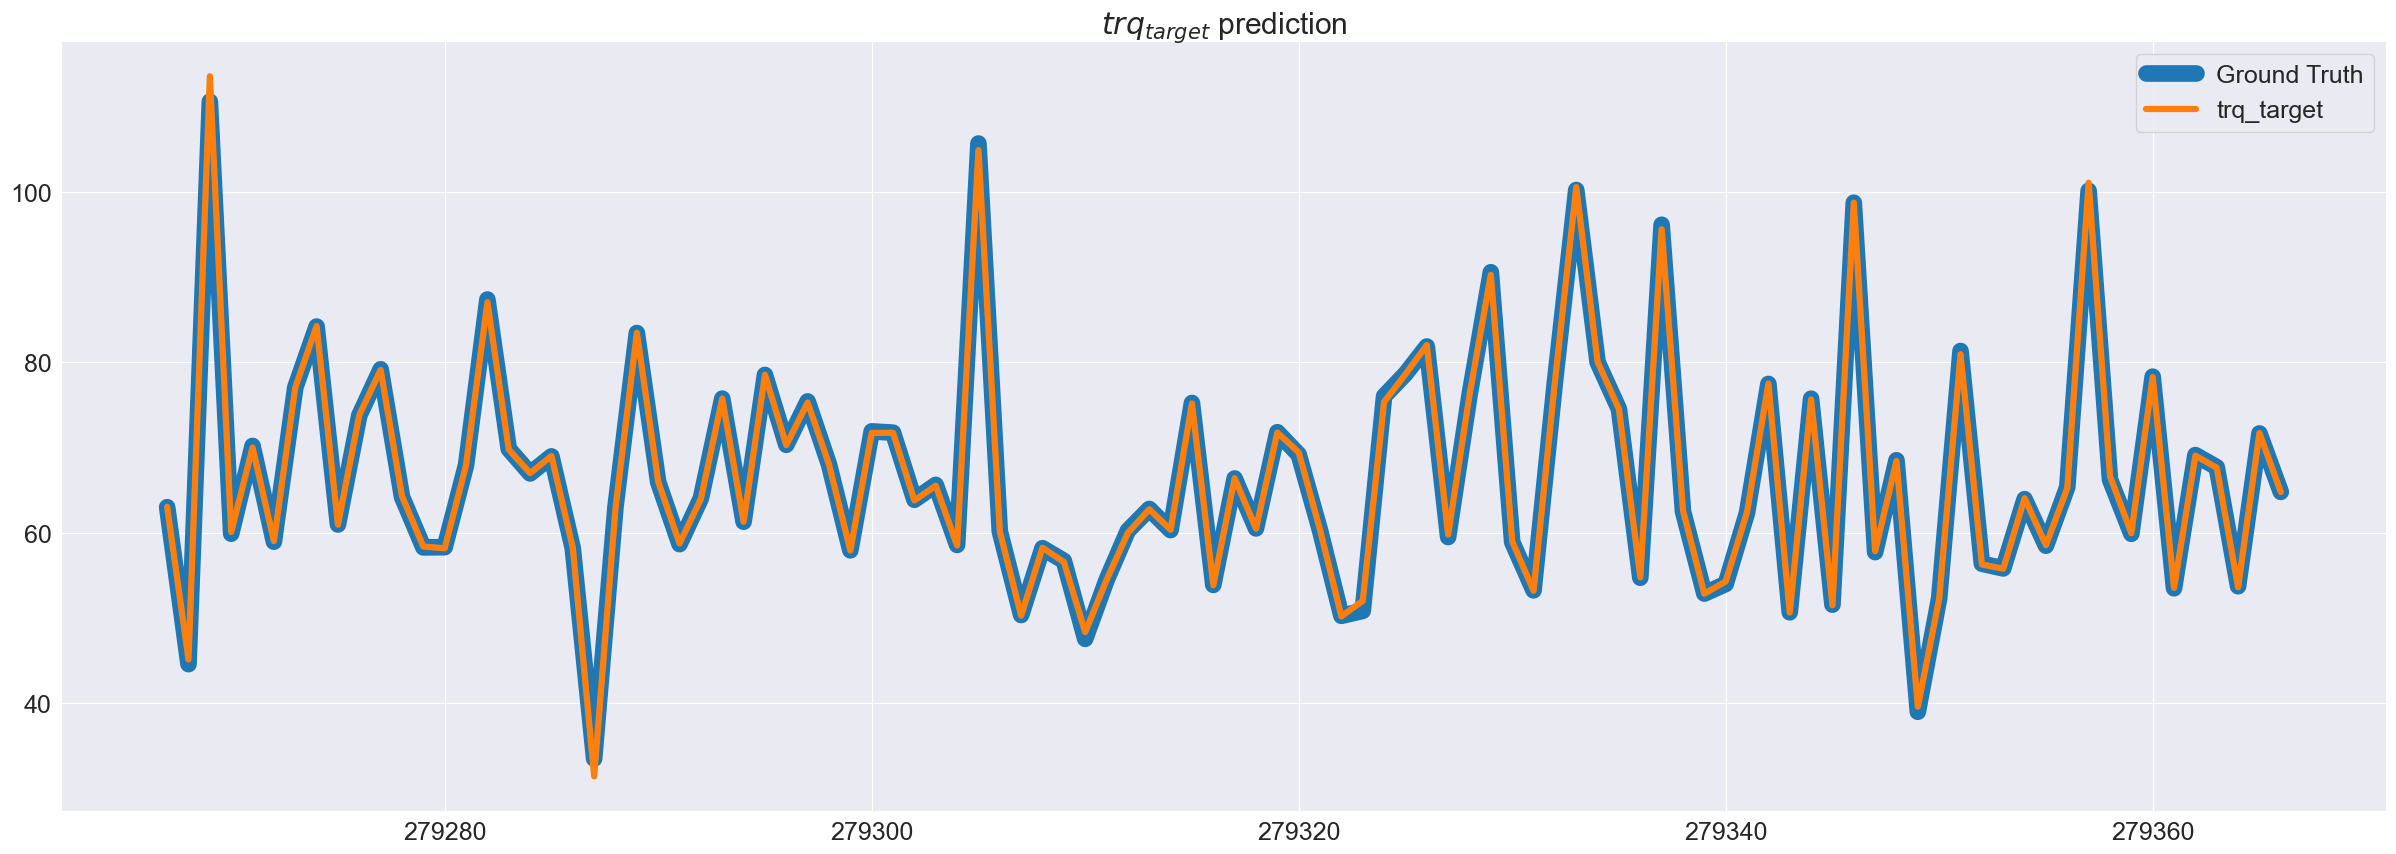

In [64]:
LENGTH = 100
i = random.randint(0, len(df_y) - LENGTH)
ax = df_y[i:i + LENGTH].plot(figsize=(30, 10), linewidth=12, label='Ground Truth')
prediction[i:i + LENGTH].plot(ax=ax, linestyle='-', linewidth=4.5, label='Predicted')
ax.legend()
ax.set_title('$trq_{target}$ prediction')

In [67]:
prediction['trq_margin'] = (df_x['trq_measured'] / prediction['trq_target'] - 1) * 100
prediction.to_csv('prediction.csv', index=False)